In [1]:
#Библиотеки
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
accuracy_score, confusion_matrix, 
precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
#Загружаем данные
df = pd.read_csv("telecom_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Проверяем пропуски в данных
df_cleaned = df.copy()
df_cleaned.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
#Удалим неиформативный столбец customerID
df_cleaned = df_cleaned.drop(columns="customerID", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Заменим пропуски на nan
df_cleaned["TotalCharges"]= df_cleaned["TotalCharges"].replace(" ",np.nan)
#Преобразуем тип колонки
df_cleaned["TotalCharges"]= df_cleaned["TotalCharges"].astype(float)
#Заменим nan на медианное значение
df_cleaned["TotalCharges"]= df_cleaned["TotalCharges"].fillna(df_cleaned["TotalCharges"].median())
df_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
#Сколько уникальных значений в каждом столбце
df_cleaned.select_dtypes(include="object").nunique()

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64

### Очиста и препроцессинг

In [7]:
categorial_features = ['Partner', 'Dependents', 'PhoneService', 
                       'PaperlessBilling', 'Churn']
binary_mapping  = {'Yes': 1, 'No': 0}

df_cleaned[categorial_features] = df_cleaned[categorial_features].replace(binary_mapping)
df_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [8]:
# Кодируем категориальные переменные
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
ohe_columns = ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod', 
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies']
ohe_transform = ohe.fit_transform(df[ohe_columns])

ohe_transform.head()

,gender_Female,gender_Male,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [9]:
# Добавляем закодированные колонки в датафрейм
df_cleaned = df_cleaned.drop(ohe_columns, axis=1).join(ohe_transform)
df_cleaned.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,0,1,0,1,29.85,29.85,0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,0,0,34,1,0,56.95,1889.50,0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0,0,0,2,1,1,53.85,108.15,1,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,0,0,45,0,0,42.30,1840.75,0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0,0,0,2,1,1,70.70,151.65,1,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


<Axes: >

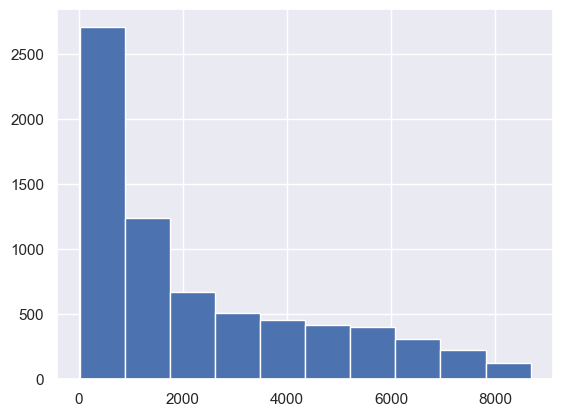

In [10]:
df_cleaned.TotalCharges.hist()

In [11]:
for col in df_cleaned.columns:
    df_cleaned.astype({col: 'float64'})

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            7043 non-null   int64  
 1   Partner                                  7043 non-null   int64  
 2   Dependents                               7043 non-null   int64  
 3   tenure                                   7043 non-null   int64  
 4   PhoneService                             7043 non-null   int64  
 5   PaperlessBilling                         7043 non-null   int64  
 6   MonthlyCharges                           7043 non-null   float64
 7   TotalCharges                             7043 non-null   float64
 8   Churn                                    7043 non-null   int64  
 9   gender_Female                            7043 non-null   float64
 10  gender_Male                              7043 no

In [12]:
df_cleaned = df_cleaned.drop_duplicates()

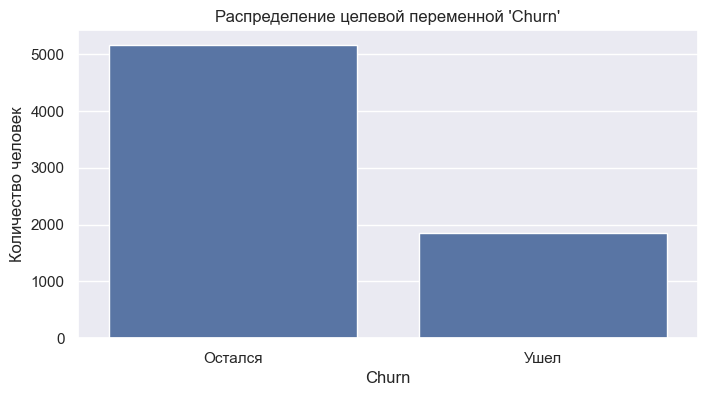

In [13]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_cleaned, x='Churn')
plt.title("Распределение целевой переменной 'Churn'")
plt.xticks(ticks=[0, 1], labels=['Остался', 'Ушел'])
plt.ylabel("Количество человек");

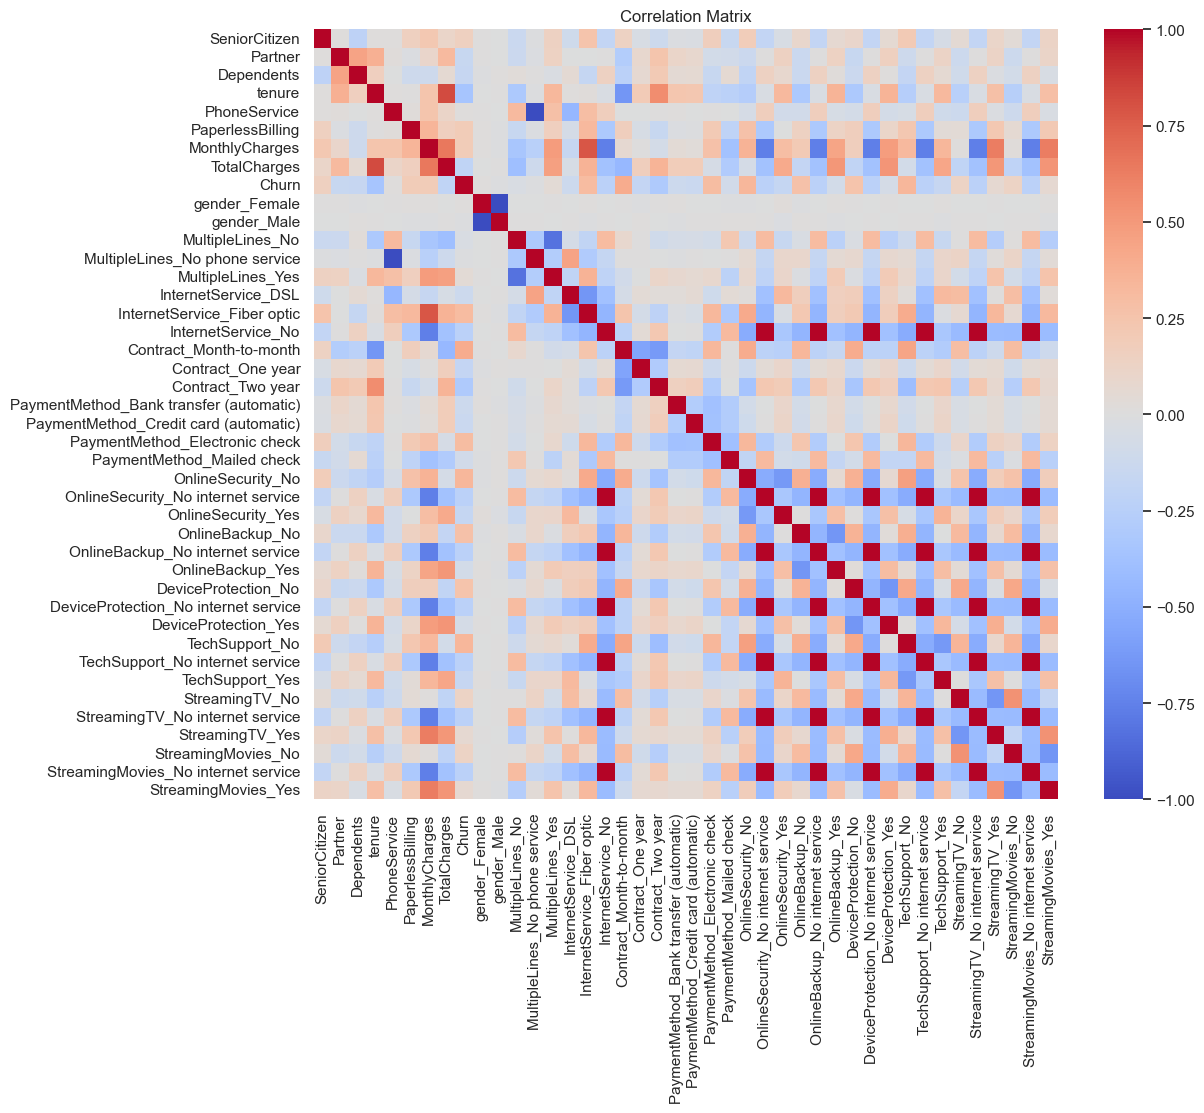

Churn                                      1.000000
Contract_Month-to-month                    0.404884
OnlineSecurity_No                          0.342255
TechSupport_No                             0.336861
InternetService_Fiber optic                0.308170
PaymentMethod_Electronic check             0.301544
OnlineBackup_No                            0.267049
DeviceProtection_No                        0.251465
MonthlyCharges                             0.194508
PaperlessBilling                           0.190891
SeniorCitizen                              0.151619
StreamingMovies_No                         0.129117
StreamingTV_No                             0.127197
StreamingTV_Yes                            0.065032
StreamingMovies_Yes                        0.063192
MultipleLines_Yes                          0.041958
PhoneService                               0.011323
gender_Female                              0.008763
gender_Male                               -0.008763
MultipleLine

In [14]:
plt.figure(figsize=(12,10))
corr = df_cleaned.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Корреляция с целевой переменной Churn
corr_churn = corr['Churn'].sort_values(ascending=False)
print(corr_churn)

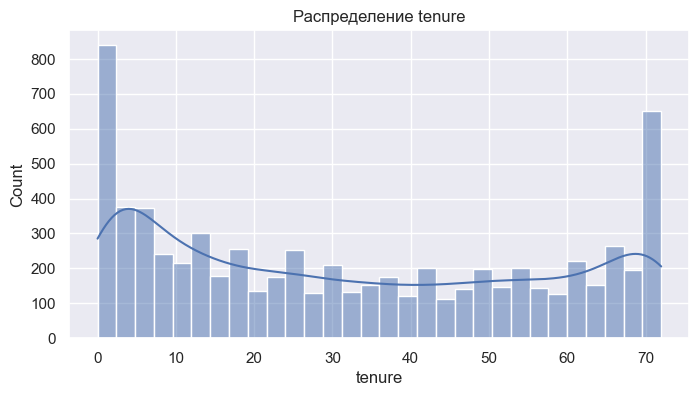

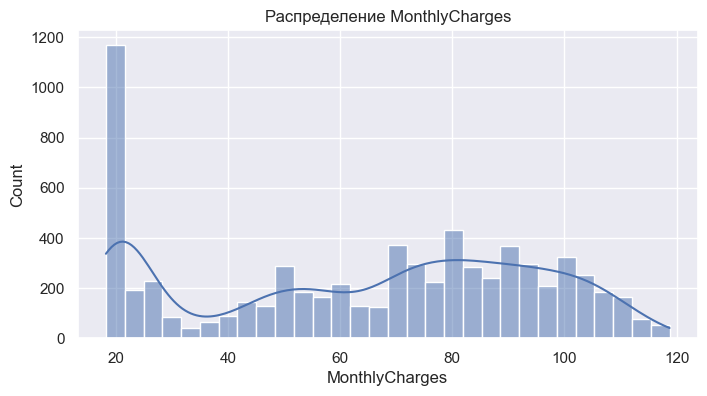

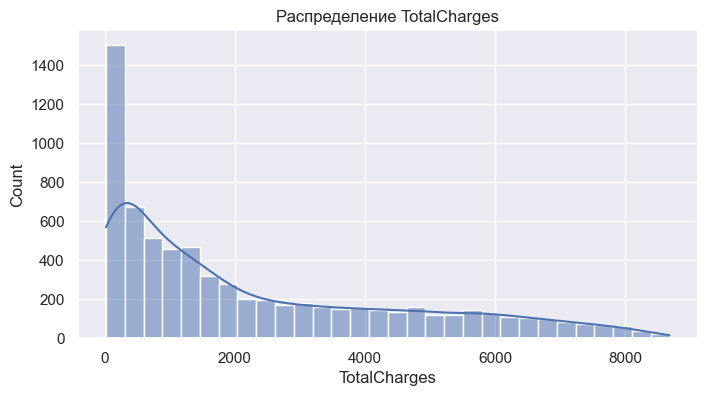

In [15]:
num_cols= ["tenure","MonthlyCharges","TotalCharges"]
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_cleaned[col], kde=True, bins=30)
    plt.title(f"Распределение {col}")
    plt.show()

### Feature Engineering и SMOTE

In [16]:
X = df_cleaned.drop("Churn", axis=1)
y = df_cleaned.Churn

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

continuous_cols = ["MonthlyCharges", 'TotalCharges', 'tenure']

scaler = StandardScaler()

X_train_continuous_scaled = scaler.fit_transform(X_train[continuous_cols])
X_test_continuous_scaled = scaler.transform(X_test[continuous_cols])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = X_train_continuous_scaled
X_test_scaled[continuous_cols] = X_test_continuous_scaled

In [17]:
# Функция для оценки качества работы модели
def get_model_metrics(model):
    y_pred = model.predict(X_test_scaled)
    accuracy = round(accuracy_score(y_test, y_pred), 3)
    recall = round(recall_score(y_test, y_pred), 3)
    precision = round(precision_score(y_test, y_pred), 3)
    f1 = round(f1_score(y_test, y_pred), 3)
    if (model.score(X_train_scaled, y_train) - accuracy)*100 > 5:
        print("Модель переообучена. Разница трейна и теста:", round((model.score(X_train_scaled, y_train) - accuracy)*100, 2))
    print(f"Accuracy: {accuracy}")
    print(f"Recall score: {recall}")
    print(f"Precision score: {precision}")
    print(f"F1 score: {f1}")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Матрица ошибок')
    plt.xlabel("Prediction")
    plt.ylabel("Real Value")
    plt.show()

## Обучаем модели

#### 1. Baseline Random Forest

In [18]:
baseline_forest = RandomForestClassifier(random_state=42, class_weight='balanced')
baseline_forest.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Модель переообучена. Разница трейна и теста: 20.62
Accuracy: 0.791
Recall score: 0.451
Precision score: 0.608
F1 score: 0.518


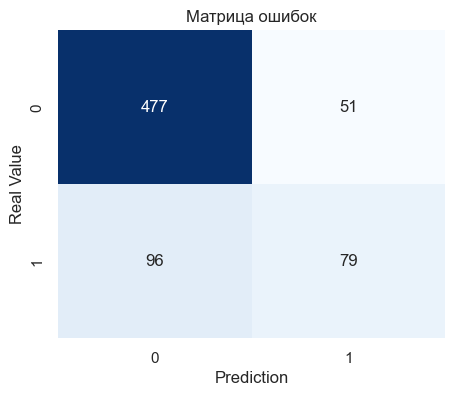

In [19]:
get_model_metrics(baseline_forest)

#### 2. Random Forest с настроенными гиперпараметрами с помощью RandomizedSearchCV

In [20]:
param_rf = {
    'n_estimators': [350,400,450,500,600,700,800],
    'max_depth': [3,5,7],
    'min_samples_split': [2,3,10],
    'min_samples_leaf': [1,5,10],
    'bootstrap': [True,False]
}

random_search = RandomizedSearchCV(
    estimator=baseline_forest,
    param_distributions=param_rf,
    n_iter=50, 
    cv=5,                 
    scoring='precision', 
    refit = "recall_macro", 
    verbose=2,
    random_state=42,
    n_jobs=-1             
)

random_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [3, 5, 7],
                                        'min_samples_leaf': [1, 5, 10],
                                        'min_samples_split': [2, 3, 10],
                                        'n_estimators': [350, 400, 450, 500,
                                                         600, 700, 800]},
                   random_state=42, refit='recall_macro', scoring='precision',
                   verbose=2)

In [21]:
best_rf = random_search.best_estimator_
random_search.score(X_train_scaled, y_train)

0.5586724614776768

Accuracy: 0.765
Recall score: 0.777
Precision score: 0.519
F1 score: 0.622


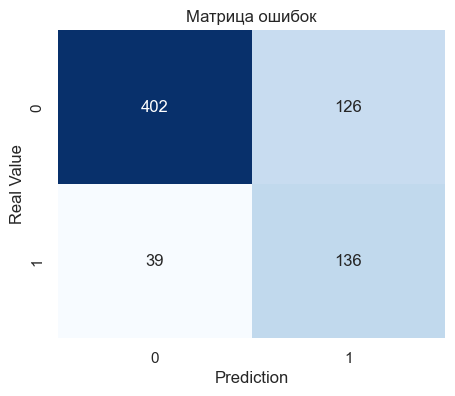

In [22]:
get_model_metrics(random_search)

По результатам RandomizedSearchCV наилучшими найденными гиперпараметрами являются:

- **n_estimators:** 400  
- **min_samples_split:** 2  
- **min_samples_leaf:** 1  
- **max_depth:** 15  
- **bootstrap:** True  

#### 3. XGBClassifier с настроенными гиперпараметрами с помощью RandomizedSearchCV

In [23]:
xgb_model_baseline = XGBClassifier(random_state=42)

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

param_xgb = {
    "n_estimators": [100, 200, 300, 400, 500, 600, 700, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.07, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8],
    "gamma": [0, 0.05, 0.1, 0.2, 0.3, 0.4],
    "reg_alpha": [0, 0.1, 0.5, 1, 2, 3, 5],
    "reg_lambda": [0.5, 1, 1.5, 2, 3, 5],
    "min_child_weight": [1, 2, 3, 4, 5],
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_baseline,
    param_distributions=param_xgb,
    n_iter=50,
    cv=5,
    scoring={
        "f1_macro": "f1_macro",
        "f1_weighted":"f1_weighted",
        "recall_macro":"recall_macro"
    },
    refit = "f1_weighted",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                                          0.05, 0.07, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 2, 3, 4, 5],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800],
                                        'reg_alpha': [0, 0.1, 0.5, 1, 2, 3, 5],
                                        'reg_lambda': [0.5, 1, 1.5, 2, 3, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, refit='f1_weighted',
                   scoring={'f1_macro': 'f1_macro',
                            'f1_weighted': 'f1_weighted',
                            'recall_macro': 'recall_macro'},
                   verbose=2)

Модель переообучена. Разница трейна и теста: 10.01
Accuracy: 0.757
Recall score: 0.691
Precision score: 0.508
F1 score: 0.586


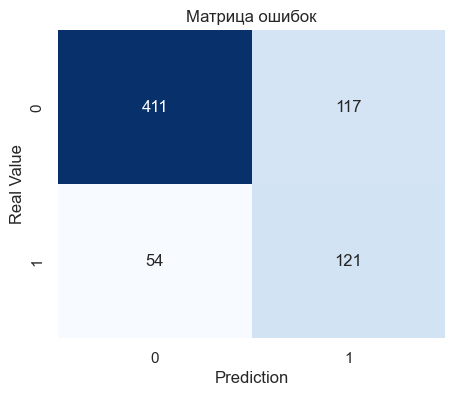

In [24]:
best_xgb = random_search_xgb.best_estimator_
get_model_metrics(random_search_xgb)

### 4. Стекинг XGBoostClassifier и RandomForestClassifier

In [25]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('random_forest', best_rf),
    ('xgboost', best_xgb)
]

param_meta = {
    'final_estimator__C': [0.1, 1.0, 10.0],
    'final_estimator__solver': ['liblinear', 'lbfgs']
}

stacking_ensemble = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5  
)

stacking_grid = GridSearchCV(
    estimator=stacking_ensemble,
    param_grid=param_meta,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

stacking_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3,
             estimator=StackingClassifier(cv=5,
                                          estimators=[('random_forest',
                                                       RandomForestClassifier(class_weight='balanced',
                                                                              max_depth=7,
                                                                              min_samples_split=10,
                                                                              n_estimators=700,
                                                                              random_state=42)),
                                                      ('xgboost',
                                                       XGBClassifier(base_score=None,
                                                                     booster=None,
                                                                     callbacks=None,
                                                                     colsample_bylevel=None,
                                                                     colsample_bynode=None,
                                                                     colsample_bytree=0.5,
                                                                     device=None,
                                                                     early_s...
                                                                     max_depth=5,
                                                                     max_leaves=None,
                                                                     min_child_weight=2,
                                                                     missing=nan,
                                                                     monotone_constraints=None,
                                                                     multi_strategy=None,
                                                                     n_estimators=600,
                                                                     n_jobs=None,
                                                                     num_parallel_tree=None, ...))],
                                          final_estimator=LogisticRegression(class_weight='balanced')),
             n_jobs=-1,
             param_grid={'final_estimator__C': [0.1, 1.0, 10.0],
                         'final_estimator__solver': ['liblinear', 'lbfgs']},
             scoring='f1_weighted')

Accuracy: 0.768
Recall score: 0.76
Precision score: 0.524
F1 score: 0.62


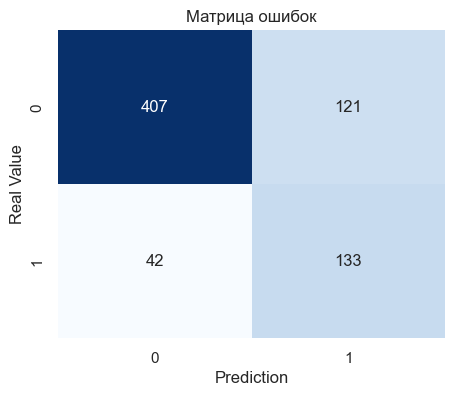

In [26]:
get_model_metrics(stacking_grid)